# Question 1: Data Profiling

## Objective

The objective of this section is to perform data profiling on the Mystery Ops Dataset to understand its structure, quality, and characteristics before conducting further diagnostic analysis.

The dataset contains operational records from multiple depots, including variables such as throughput, operating temperature, maintenance status, voltage count, shift information, and incident type. Data profiling helps identify the quality of the dataset by examining its dimensions, data types, summary statistics, and missing values.

A complete univariate analysis is performed to understand the distribution of each variable individually using descriptive statistics and visualizations such as histograms, boxplots, and count plots. These analyses help identify trends, variability, skewness, and potential outliers.

A bivariate analysis is then conducted to examine relationships between numerical and categorical variables. Correlation analysis, scatter plots, boxplots, and cross-tabulations are used to identify operational patterns and relationships that may influence system performance. The findings from this analysis will guide subsequent data cleaning and diagnostic investigations.

First Five Records


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,15/10/2026,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,18/05/2026,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,09/02/2026,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,18/03/2026,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


Dataset Shape
(2920, 11)
Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           2920 non-null   str    
 1   operation_date      2920 non-null   str    
 2   depot               2920 non-null   str    
 3   shift               2920 non-null   str    
 4   operator_id         2902 non-null   str    
 5   machine_id          2920 non-null   str    
 6   throughput_barrels  2915 non-null   float64
 7   temperature_c       2900 non-null   float64
 8   maintenance_flag    2920 non-null   int64  
 9   voltage_count       2920 non-null   int64  
 10  incident_type       2920 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 251.1 KB
Summary Statistics (Numerical)


,throughput_barrels,temperature_c,maintenance_flag,voltage_count
count,2915.000000,2900.000000,2920.000000,2920.000000
mean,916.891149,25.050310,0.186644,221.122945
std,168.122566,5.567664,0.389692,6.518187
min,296.500000,10.900000,0.000000,197.000000
25%,872.850000,21.200000,0.000000,217.000000
50%,969.300000,25.100000,0.000000,221.000000
75%,1029.650000,29.100000,0.000000,225.000000
max,1210.600000,39.900000,1.000000,242.000000


Summary Statistics (Categorical)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14344\2249842065.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,record_id,operation_date,depot,shift,operator_id,machine_id,incident_type
count,2920,2920,2920,2920,2902,2920,2920
unique,2920,365,4,2,15,13,4
top,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-E02,NBI-P03,none
freq,1,8,730,1460,253,566,2332


Missing Value Summary


,Missing Count,Missing Percentage
record_id,0,0.00
operation_date,0,0.00
depot,0,0.00
shift,0,0.00
operator_id,18,0.62
machine_id,0,0.00
throughput_barrels,5,0.17
temperature_c,20,0.68
maintenance_flag,0,0.00
voltage_count,0,0.00


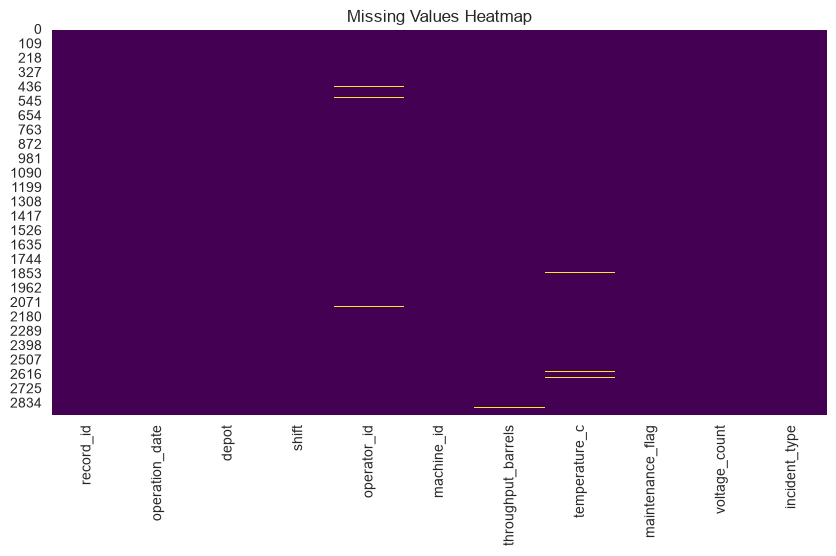

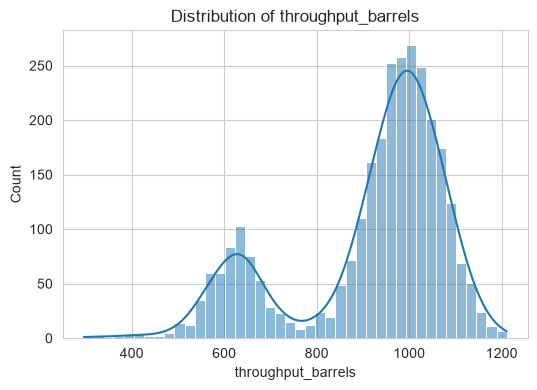

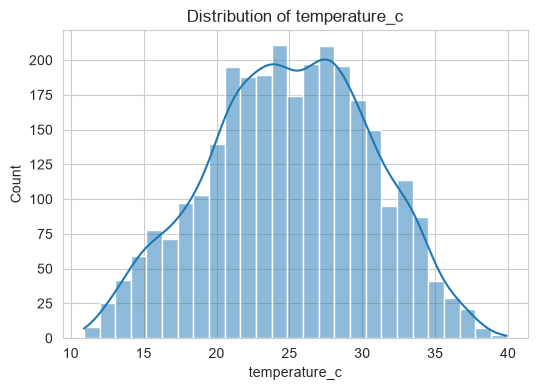

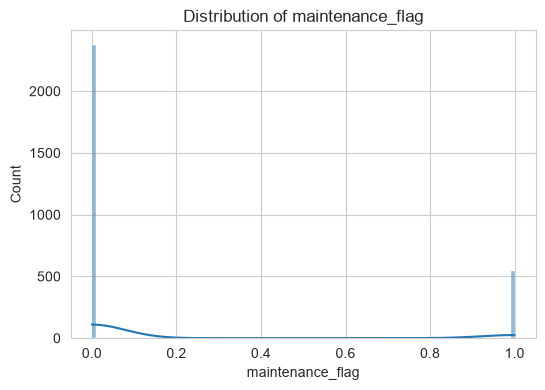

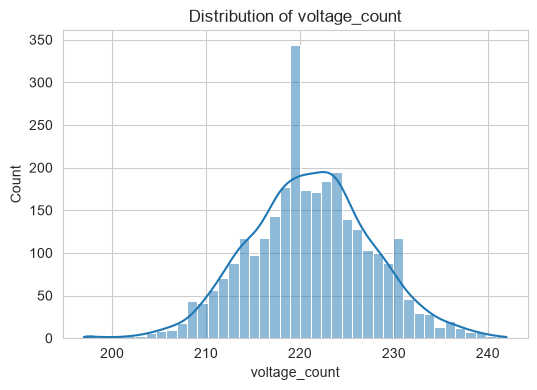

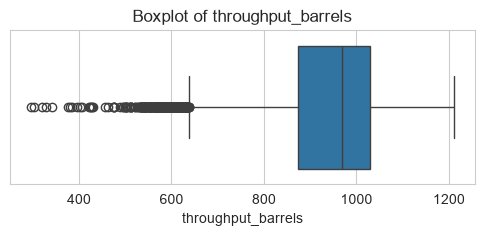

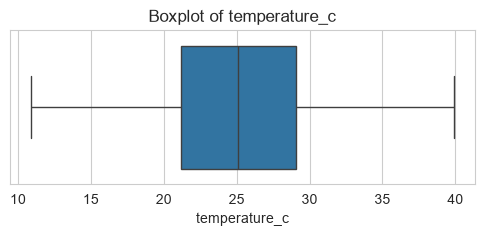

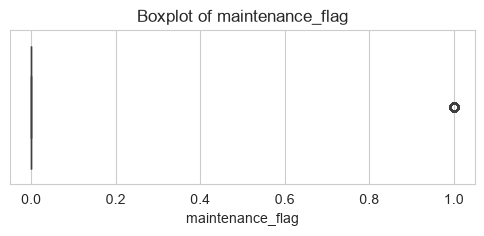

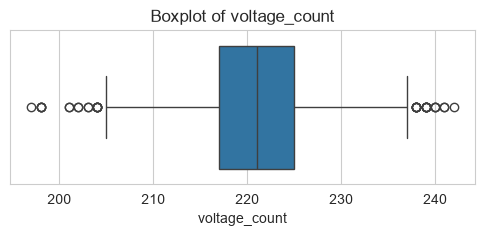

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14344\2249842065.py:52: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


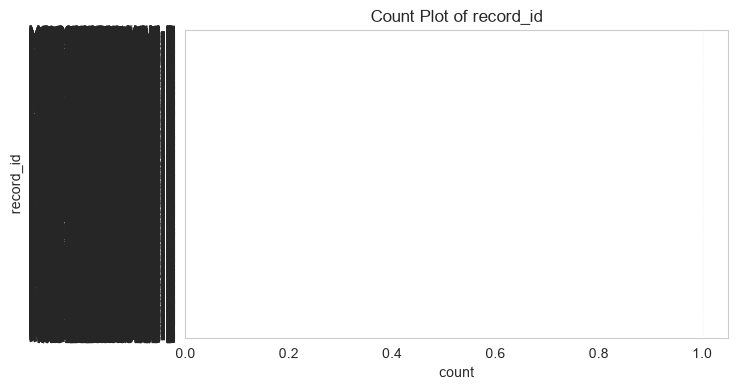

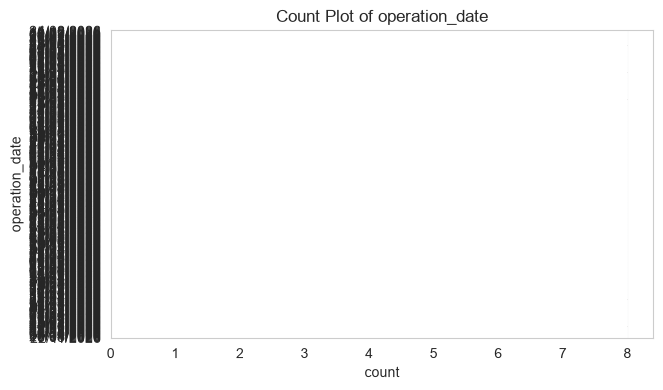

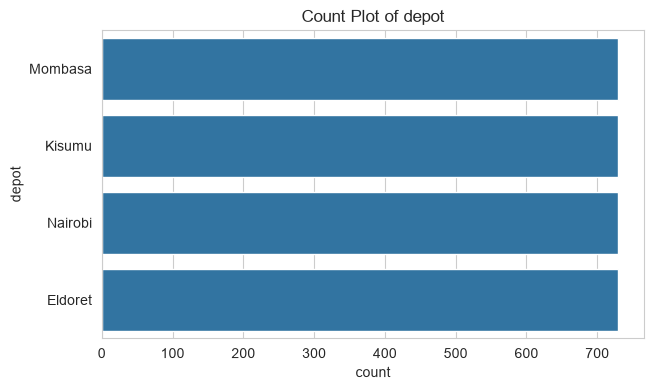

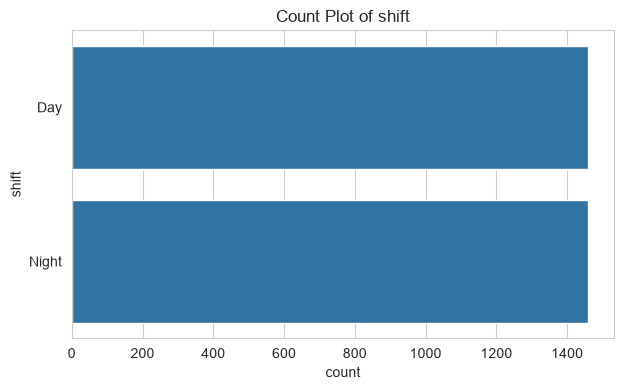

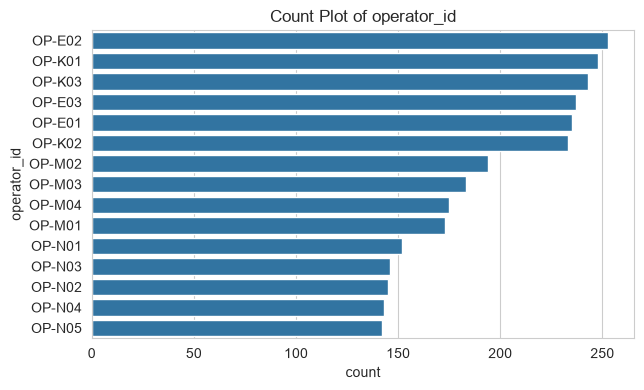

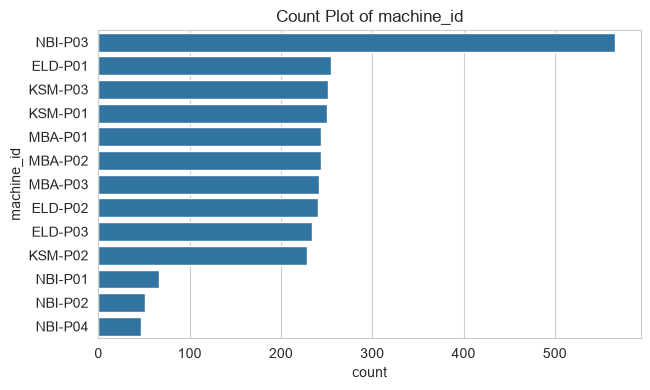

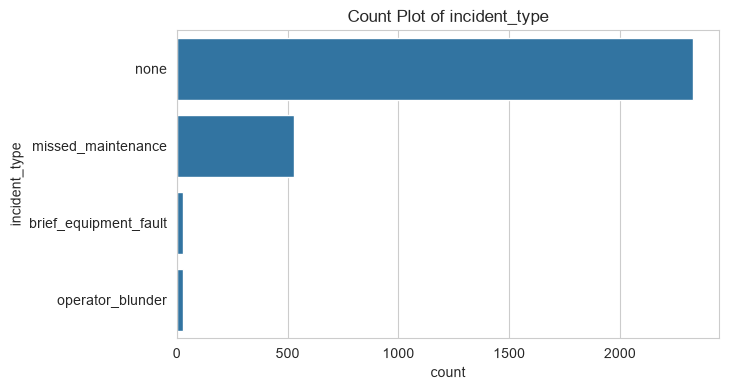

Correlation Matrix


,throughput_barrels,temperature_c,maintenance_flag,voltage_count
throughput_barrels,1.000000,0.251951,-0.852937,0.038939
temperature_c,0.251951,1.000000,-0.124011,-0.004099
maintenance_flag,-0.852937,-0.124011,1.000000,0.018611
voltage_count,0.038939,-0.004099,0.018611,1.000000


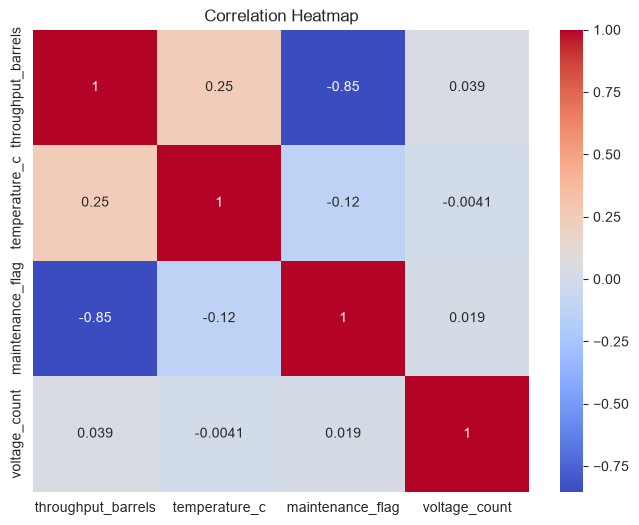

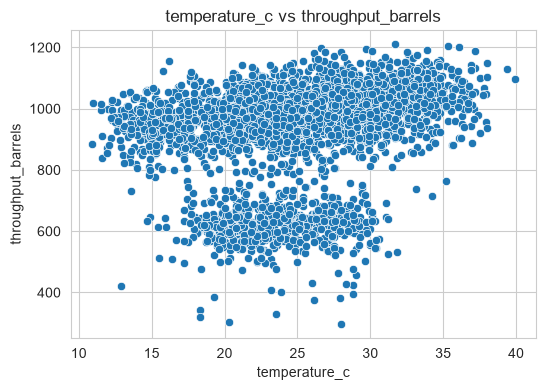

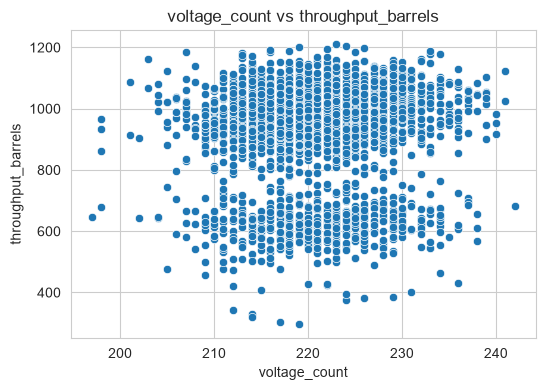

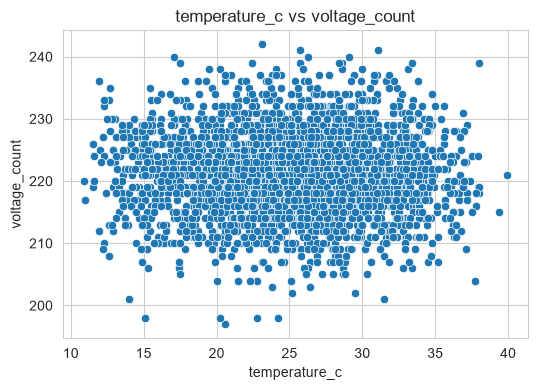

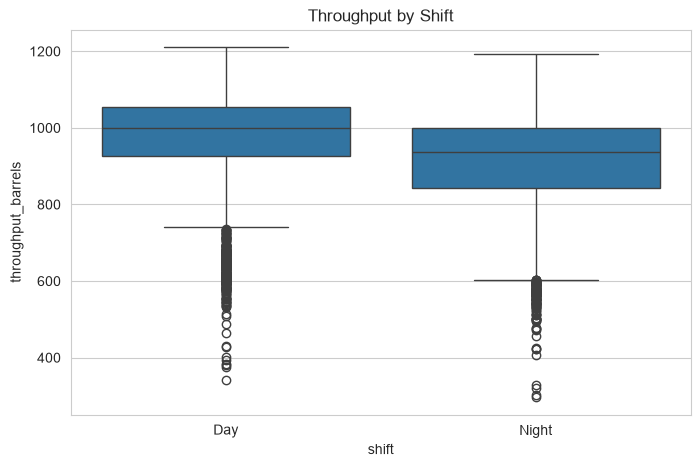

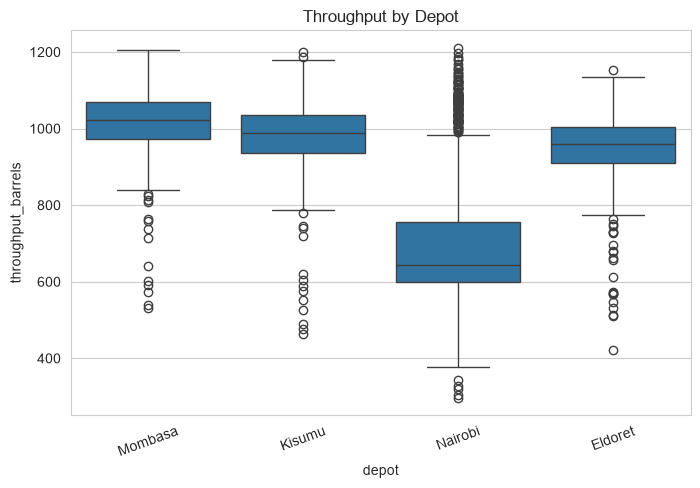

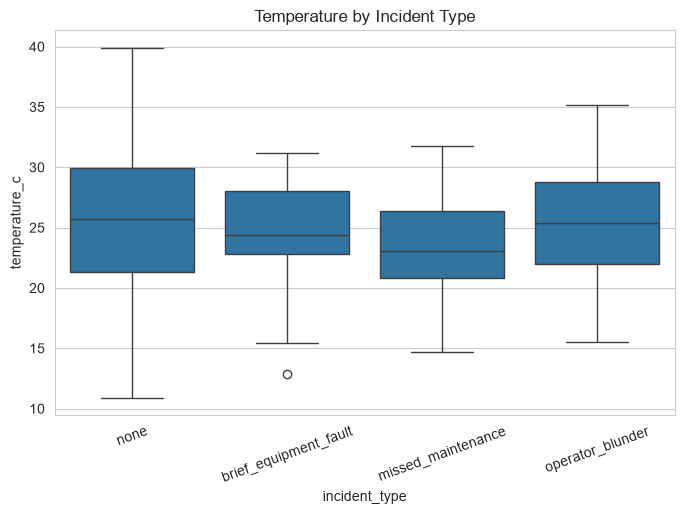

Depot vs Shift


shift,Day,Night
depot,,
Eldoret,365,365
Kisumu,365,365
Mombasa,365,365
Nairobi,365,365


Shift vs Incident Type


incident_type,brief_equipment_fault,missed_maintenance,none,operator_blunder
shift,,,,
Day,13,262,1170,15
Night,17,267,1162,14


Maintenance Flag vs Incident Type


incident_type,brief_equipment_fault,missed_maintenance,none,operator_blunder
maintenance_flag,,,,
0,18,0,2332,25
1,12,529,0,4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("Mystery_Ops.csv")

print("First Five Records")
display(df.head())

print("Dataset Shape")
print(df.shape)

print("Dataset Information")
df.info()

print("Summary Statistics (Numerical)")
display(df.describe())

print("Summary Statistics (Categorical)")
display(df.describe(include="object"))

missing_profile = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": round(df.isna().mean() * 100, 2)
})

print("Missing Value Summary")
display(missing_profile)

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Count Plot of {col}")
    plt.show()

corr = df.corr(numeric_only=True)

print("Correlation Matrix")
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

numeric_pairs = [
    ("temperature_c", "throughput_barrels"),
    ("voltage_count", "throughput_barrels"),
    ("temperature_c", "voltage_count")
]

for x, y in numeric_pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="shift", y="throughput_barrels")
plt.title("Throughput by Shift")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="depot", y="throughput_barrels")
plt.title("Throughput by Depot")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="incident_type", y="temperature_c")
plt.title("Temperature by Incident Type")
plt.xticks(rotation=20)
plt.show()

print("Depot vs Shift")
display(pd.crosstab(df["depot"], df["shift"]))

print("Shift vs Incident Type")
display(pd.crosstab(df["shift"], df["incident_type"]))

print("Maintenance Flag vs Incident Type")
display(pd.crosstab(df["maintenance_flag"], df["incident_type"]))

# Question 2: Anomaly Detection

## Objective

The purpose of this analysis is to identify significant anomalies or outliers within the Mystery Ops Dataset. Detecting anomalies helps uncover unusual operational patterns that may indicate equipment malfunctions, data entry errors, or unexpected operational events requiring further investigation.

Box plots are used to identify extreme values in numerical variables by comparing observations against the interquartile range (IQR). Scatter plots are then used to visualize relationships between variables and highlight observations that deviate from the overall trend. In this analysis, throughput, operating temperature, and voltage count are examined to identify operational anomalies that could affect depot performance and decision-making.

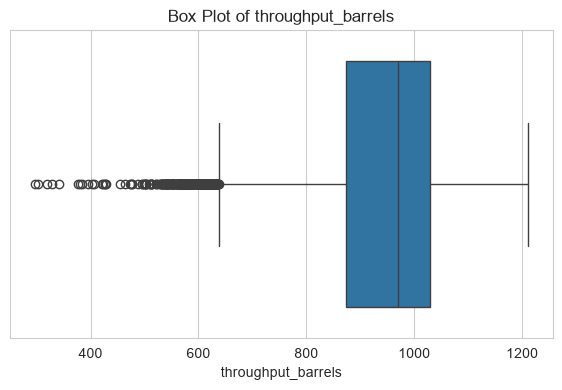

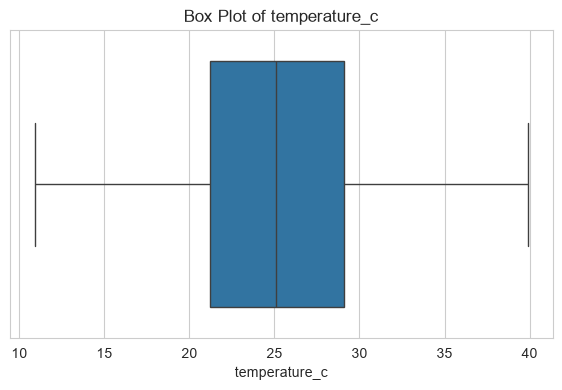

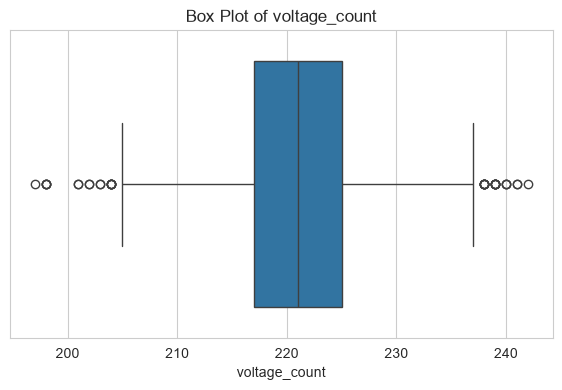

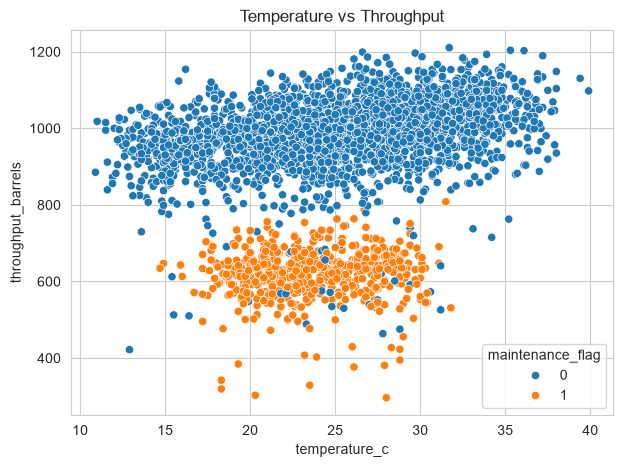

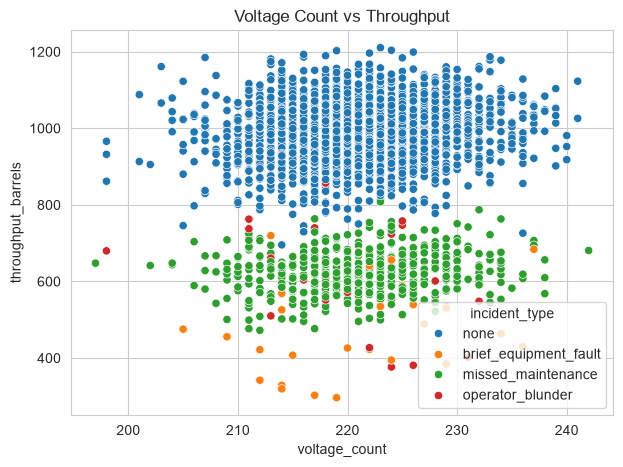

Potential Outliers in Throughput


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
12,MO-20260402-ELD-N,02/04/2026,Eldoret,Night,OP-E02,ELD-P02,531.5,27.4,0,221,brief_equipment_fault
25,MO-20260417-NAI-N,17/04/2026,Nairobi,Night,OP-N04,NBI-P03,422.8,28.8,1,222,brief_equipment_fault
57,MO-20260512-NAI-N,12/05/2026,Nairobi,Night,OP-N05,NBI-P03,536.2,25.3,1,223,missed_maintenance
59,MO-20260421-MOM-N,21/04/2026,Mombasa,Night,OP-M04,MBA-P01,572.9,30.6,0,214,operator_blunder
60,MO-20260815-NAI-N,15/08/2026,Nairobi,Night,OP-N01,NBI-P03,568.1,24.1,1,238,missed_maintenance
...,...,...,...,...,...,...,...,...,...,...,...
2862,MO-20261026-NAI-N,26/10/2026,Nairobi,Night,OP-N01,NBI-P03,472.5,21.2,1,212,missed_maintenance
2872,MO-20260311-NAI-N,11/03/2026,Nairobi,Night,OP-N02,NBI-P03,592.7,29.8,1,226,missed_maintenance
2880,MO-20261022-NAI-D,22/10/2026,Nairobi,Day,OP-N03,NBI-P03,627.4,22.7,1,220,missed_maintenance
2887,MO-20260228-NAI-N,28/02/2026,Nairobi,Night,OP-N01,NBI-P03,631.6,28.1,1,209,missed_maintenance


Potential Outliers in Temperature


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type


In [2]:


numerical_columns = [
    "throughput_barrels",
    "temperature_c",
    "voltage_count"
]

for column in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="temperature_c",
    y="throughput_barrels",
    hue="maintenance_flag"
)
plt.title("Temperature vs Throughput")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="voltage_count",
    y="throughput_barrels",
    hue="incident_type"
)
plt.title("Voltage Count vs Throughput")
plt.show()

print("Potential Outliers in Throughput")
Q1 = df["throughput_barrels"].quantile(0.25)
Q3 = df["throughput_barrels"].quantile(0.75)
IQR = Q3 - Q1

throughput_outliers = df[
    (df["throughput_barrels"] < Q1 - 1.5 * IQR) |
    (df["throughput_barrels"] > Q3 + 1.5 * IQR)
]

display(throughput_outliers)

print("Potential Outliers in Temperature")
Q1 = df["temperature_c"].quantile(0.25)
Q3 = df["temperature_c"].quantile(0.75)
IQR = Q3 - Q1

temperature_outliers = df[
    (df["temperature_c"] < Q1 - 1.5 * IQR) |
    (df["temperature_c"] > Q3 + 1.5 * IQR)
]

display(temperature_outliers)

# Question 3: Root Cause Analysis

## Objective

The purpose of this analysis is to identify the underlying factors contributing to operational issues within the Mystery Ops Dataset. Root cause analysis helps determine where problems are occurring, which causes contribute the most to operational disruptions, and whether relationships exist between key operational variables.

A drill-down analysis is performed by grouping the data by depot, shift, and incident type to isolate areas with the highest number of incidents and operational challenges. Pareto analysis is then used to identify the small number of incident categories responsible for the majority of occurrences, following the 80/20 principle. Finally, correlation analysis is conducted to determine whether numerical variables such as throughput, operating temperature, and voltage count are significantly related and may explain observed operational issues. The results provide insights that support evidence-based decision-making and operational improvements.

Incidents by Depot


depot
Eldoret    730
Kisumu     730
Mombasa    730
Nairobi    730
dtype: int64

Incidents by Shift


shift
Day      1460
Night    1460
dtype: int64

Incidents by Incident Type


incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
dtype: int64

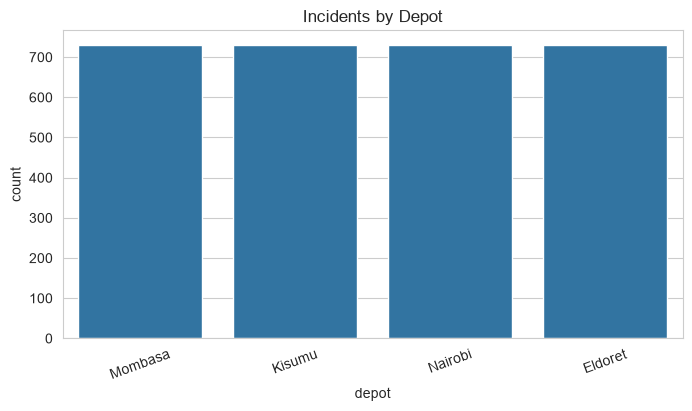

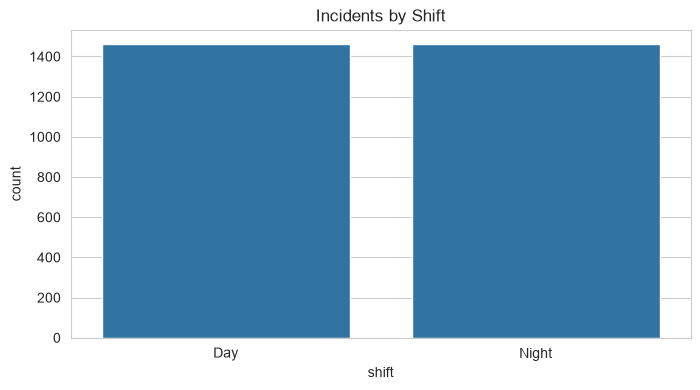

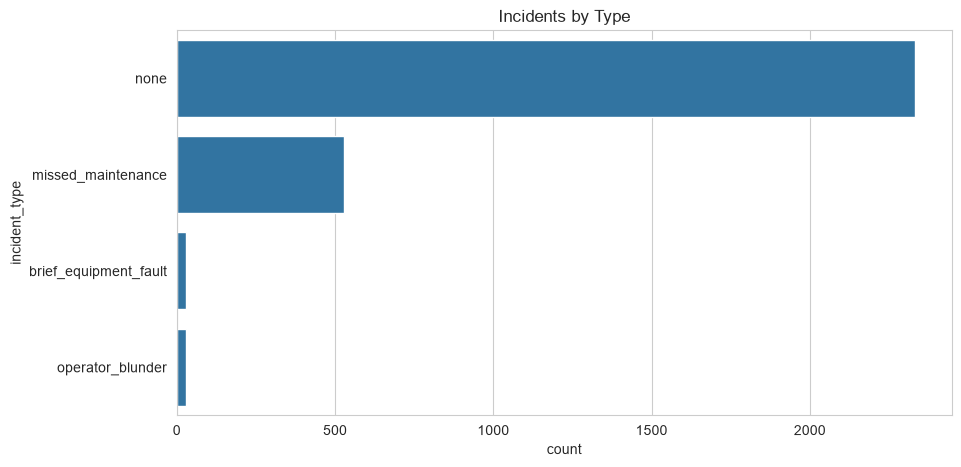

,Incident Type,Frequency,Cumulative %
0,none,2332,79.863014
1,missed_maintenance,529,97.979452
2,brief_equipment_fault,30,99.006849
3,operator_blunder,29,100.000000


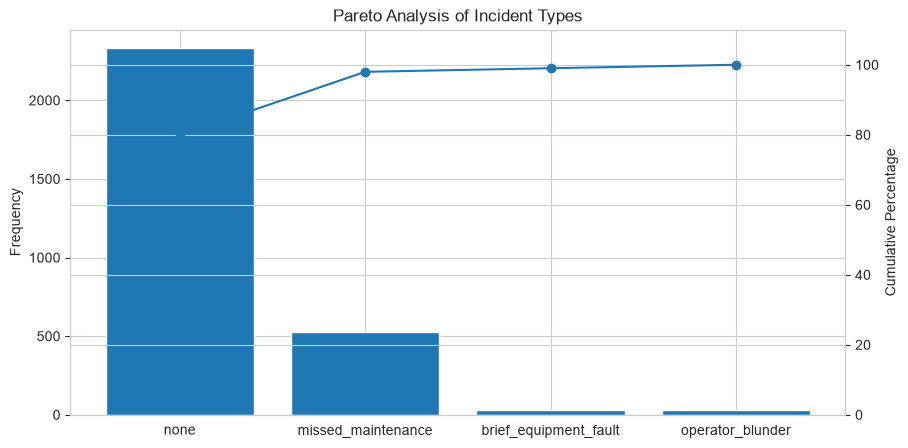

,throughput_barrels,temperature_c,voltage_count
throughput_barrels,1.000000,0.251951,0.038939
temperature_c,0.251951,1.000000,-0.004099
voltage_count,0.038939,-0.004099,1.000000


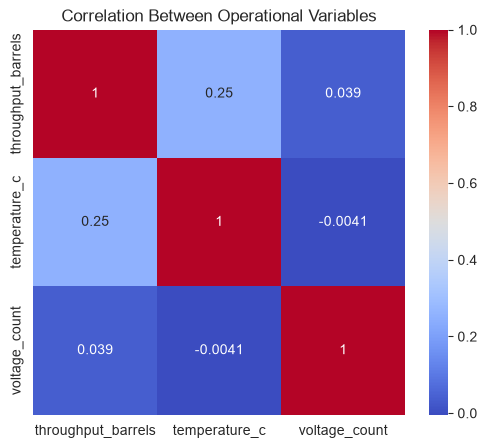

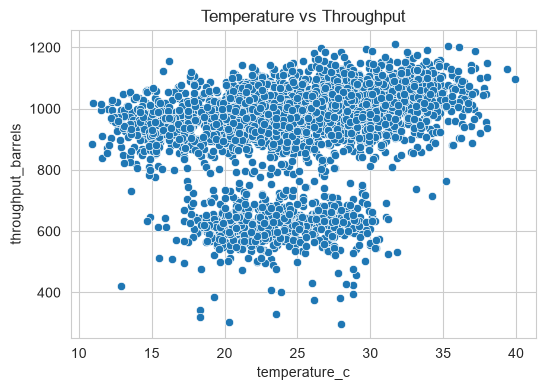

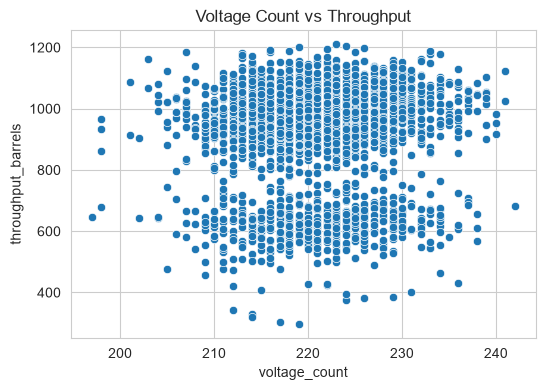

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Drill-Down Analysis
# ----------------------------

print("Incidents by Depot")
depot_summary = df.groupby("depot").size().sort_values(ascending=False)
display(depot_summary)

print("Incidents by Shift")
shift_summary = df.groupby("shift").size().sort_values(ascending=False)
display(shift_summary)

print("Incidents by Incident Type")
incident_summary = df.groupby("incident_type").size().sort_values(ascending=False)
display(incident_summary)

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="depot", order=df["depot"].value_counts().index)
plt.title("Incidents by Depot")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="shift", order=df["shift"].value_counts().index)
plt.title("Incidents by Shift")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="incident_type",
    order=df["incident_type"].value_counts().index
)
plt.title("Incidents by Type")
plt.show()

# ----------------------------
# Pareto Analysis
# ----------------------------

pareto = df["incident_type"].value_counts().reset_index()
pareto.columns = ["Incident Type", "Frequency"]

pareto["Cumulative %"] = (
    pareto["Frequency"].cumsum() /
    pareto["Frequency"].sum()
) * 100

display(pareto)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(pareto["Incident Type"], pareto["Frequency"])
ax1.set_ylabel("Frequency")

ax2 = ax1.twinx()
ax2.plot(
    pareto["Incident Type"],
    pareto["Cumulative %"],
    marker="o"
)
ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0,110)

plt.title("Pareto Analysis of Incident Types")
plt.xticks(rotation=30)
plt.show()

# ----------------------------
# Correlation Analysis
# ----------------------------

corr = df[
    ["throughput_barrels",
     "temperature_c",
     "voltage_count"]
].corr()

display(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Operational Variables")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="temperature_c",
    y="throughput_barrels"
)
plt.title("Temperature vs Throughput")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="voltage_count",
    y="throughput_barrels"
)
plt.title("Voltage Count vs Throughput")
plt.show()

# Question 4: Visualization

## Objective

The purpose of this section is to communicate the key findings from the exploratory and diagnostic analyses through clear, publication-quality visualizations. Effective visualizations make it easier to identify operational trends, compare performance across depots and shifts, and highlight factors associated with operational incidents.

Three visualizations are created using Seaborn to summarize the most important insights from the Mystery Ops Dataset. These charts illustrate the distribution of incidents across depots, compare throughput across operational shifts, and show the relationship between operating temperature and throughput. Together, these visualizations provide a concise overview of the operational challenges and support data-driven decision-making.

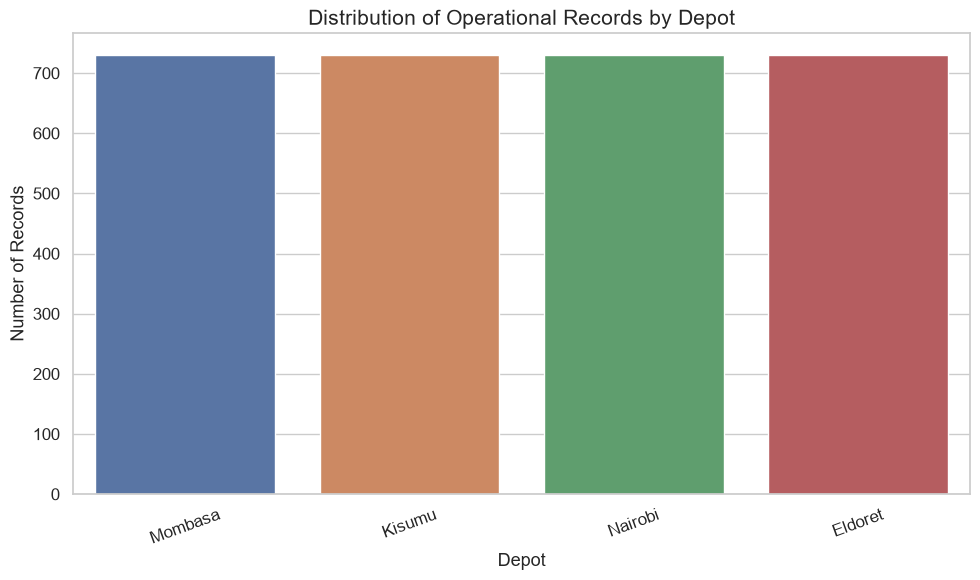

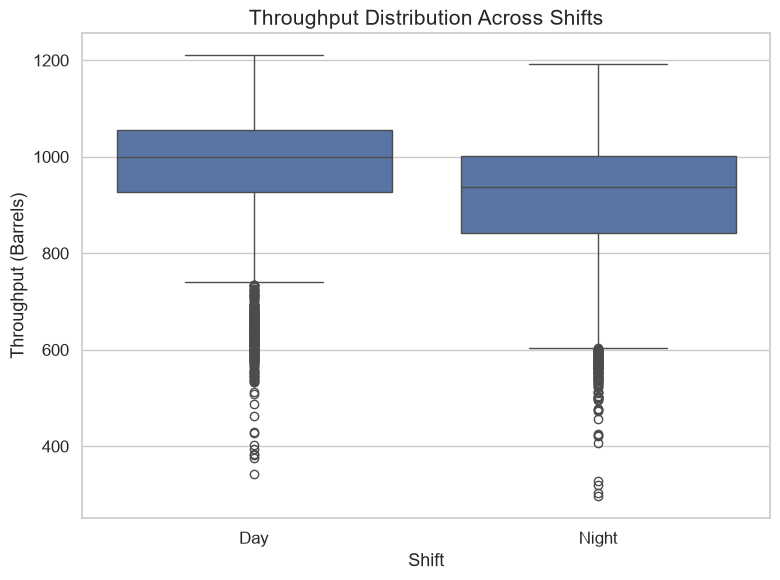

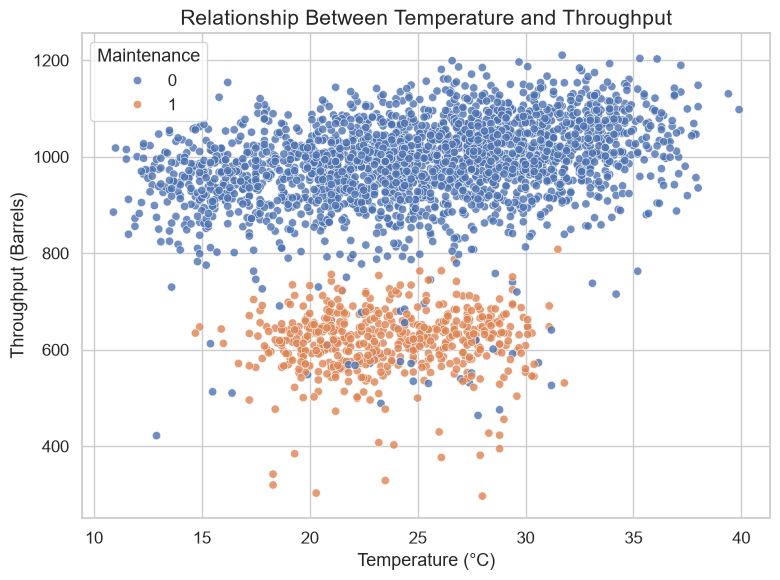

In [4]:


sns.set_theme(style="whitegrid", font_scale=1.1)

# Chart 1: Incidents by Depot
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="depot",
    order=df["depot"].value_counts().index,
    hue="depot",
    legend=False
)
plt.title("Distribution of Operational Records by Depot", fontsize=15)
plt.xlabel("Depot")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Chart 2: Throughput by Shift
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="shift",
    y="throughput_barrels"
)
plt.title("Throughput Distribution Across Shifts", fontsize=15)
plt.xlabel("Shift")
plt.ylabel("Throughput (Barrels)")
plt.tight_layout()
plt.show()

# Chart 3: Temperature vs Throughput
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="temperature_c",
    y="throughput_barrels",
    hue="maintenance_flag",
    alpha=0.8
)
plt.title("Relationship Between Temperature and Throughput", fontsize=15)
plt.xlabel("Temperature (°C)")
plt.ylabel("Throughput (Barrels)")
plt.legend(title="Maintenance")
plt.tight_layout()
plt.show()